# YOLO V8s Training #
##############################################################################################
########################################################
##############################################################################################

In [26]:
import os
import shutil
import cv2
import json
import glob
import numpy as np
#import pytesseract as pt
import matplotlib; matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
%matplotlib inline

from ultralyticsplus import render_result
from ultralytics import YOLO
#!yolo settings sync=False
#ultralytics.checks()
from huggingface_hub import hf_hub_download
from transformers import DetrFeatureExtractor
from transformers import TableTransformerForObjectDetection
from PIL import Image
import torch

import paddleocr
from paddleocr import PaddleOCR, draw_ocr
import tensorflow as tf
import tensorflow_hub as hub

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, BatchNormalization, Concatenate, Add, Activation, UpSampling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping
from tensorflow.keras.applications import VGG19
from tensorflow.keras import regularizers
from tensorflow.keras.applications.densenet import DenseNet121

In [27]:
resnet50v2_model = tf.keras.models.load_model(
           ('resnetv2_10epochs.keras'),
           custom_objects={'KerasLayer':hub.KerasLayer}
    )

09/09/2025 19:25:49 - INFO - absl -   Using C:\Users\SCC\AppData\Local\Temp\tfhub_modules to cache modules.


In [14]:
model_test = YOLO('runs/detect/train5/weights/last.pt')

In [15]:
# set model parameters
model_test.overrides['conf'] = 0.5  # NMS confidence threshold
model_test.overrides['iou'] = 0.5  # NMS IoU threshold
model_test.overrides['agnostic_nms'] = False  # NMS class-agnostic
model_test.overrides['max_det'] = 1  # maximum number of detections per image

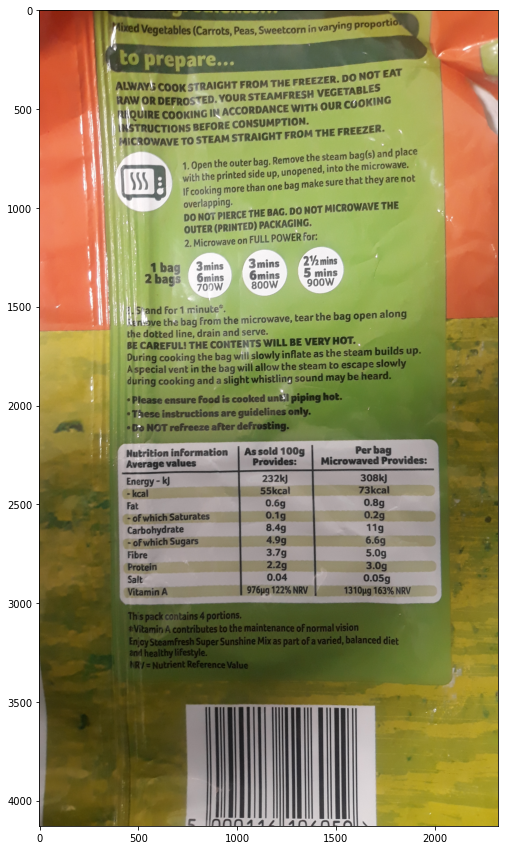

In [16]:
filepath = 'D:/Data Science/ai project refined/myfoods/20250228_125930.jpg'
#filepath = 'D:/Data Science/ai project refined/nutrition-lc-fr-country-fr-last-edit-date-2019-08/unseen_images_for_test/tables/20638382.nutrition.cropped.jpg'
#filepath = 'D:/Data Science/ai project refined/nutrition-lc-fr-country-fr-last-edit-date-2019-08/unseen_images_for_test/tables/24001120.nutrition.cropped.jpg'
#filepath = 'D:/Data Science/ai project refined/nutrition-lc-fr-country-fr-last-edit-date-2019-08/unseen_images_for_test/tables/26020969.nutrition.cropped.jpg'
#filepath = 'D:/Data Science/ai project refined/nutrition-lc-fr-country-fr-last-edit-date-2019-08/unseen_images_for_test/tables/8410283317856.nutrition.cropped.jpg'
img = cv2.imread(filepath)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15,15))
plt.grid(False)
plt.imshow(img)

### Table Classification using ResNet-50 v2 ###

In [30]:
X=[]
resized_img = cv2.resize(img,(224,224))
X.append(resized_img)
X = np.array(X)
X_train_scaled = X / 255

In [32]:
predicted = resnet50v2_model.predict(np.array([X_train_scaled[0]]))
predicted = np.argmax(predicted, axis=1)

In [33]:
print(predicted) #[1]:table [0]:non-table

[1]


### Table Detection using YOLOv8s ###

In [17]:
results_pred = model_test(img, save=True)

Ultralytics YOLOv8.0.43  Python-3.7.5 torch-1.13.1+cpu CPU
YOLOv8n summary (fused): 168 layers, 3005843 parameters, 0 gradients, 8.1 GFLOPs

WARNING  NMS time limit 0.550s exceeded
0: 640x384 1 nutrition_table, 1097.9ms
Speed: 710.6ms preprocess, 1097.9ms inference, 4558.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs\detect\predict2


E:\PYTHON_PROJECTS\NOTEBOOKS\runs\detect\predict2\image0.jpg


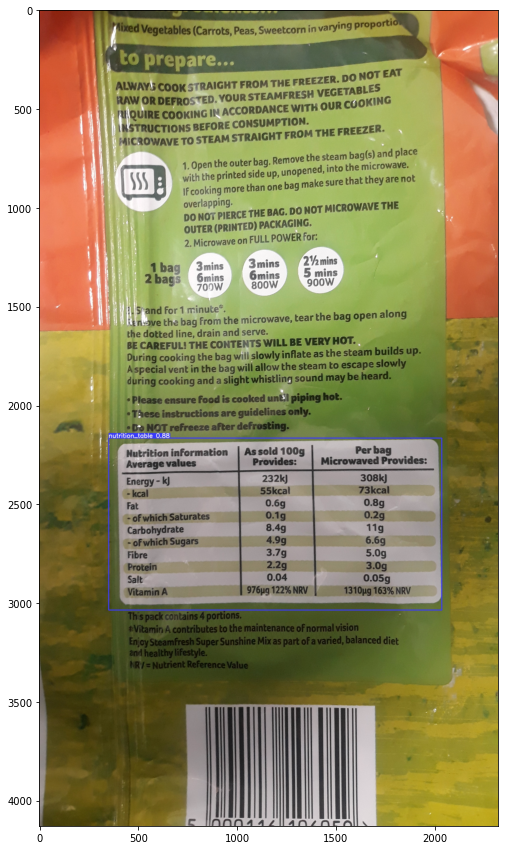

In [18]:
a = glob.glob(r'E:\PYTHON_PROJECTS\NOTEBOOKS\runs\detect\predict*')[-1]
filepath = glob.glob(a+'\\'+'*.jpg')[0]
print(filepath)
yolo_result = cv2.imread(filepath)
plt.figure(figsize=(15,15))
plt.imshow(yolo_result)

image0.png
image001234567.png


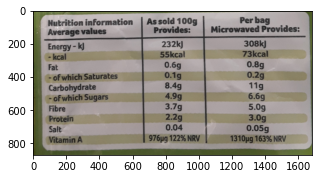

In [19]:
cropped_table = 0
dst_path = 'E:/PYTHON_PROJECTS/NOTEBOOKS/extracted_tables'
#os.chdir(directory)
filename = filepath.split('\\')[-1].split('.')[0]+'.png'
print(filename)

i=0
while os.path.exists(dst_path+'/'+filename):
    filename = filename.split('.')[0]+str(i)+'.png'
    i+=1
print(filename)

for result in results_pred:
    for box in result.boxes.xyxy:
        boxes = box.tolist()
        (x1,y1,x2,y2) = (int(boxes[0]), int(boxes[1]), int(boxes[2]), int(boxes[3]))
        cropped_table = img[y1:y2, x1:x2]
        cv2.imwrite(filename, cropped_table)
        shutil.move(os.getcwd()+'\\'+filename, dst_path)
        plt.figure(figsize=(5,5))
        plt.grid(False)
        plt.imshow(cropped_table)

### Structure Recognition using a pretrained TATR ###

09/09/2025 10:45:55 - INFO - timm.models._builder -   Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
09/09/2025 10:45:55 - INFO - timm.models._hub -   [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


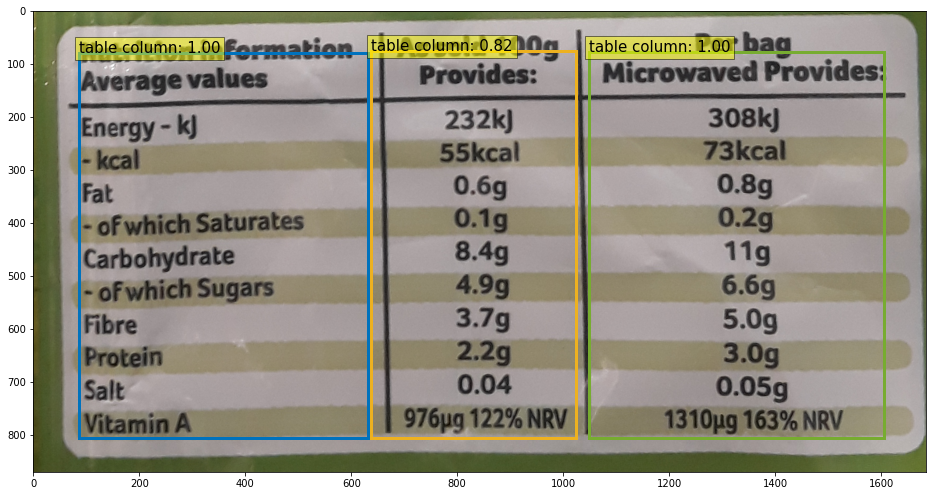

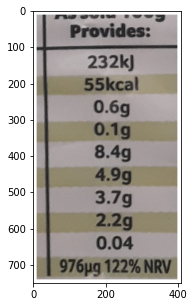

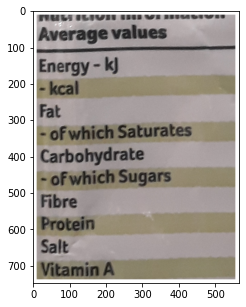

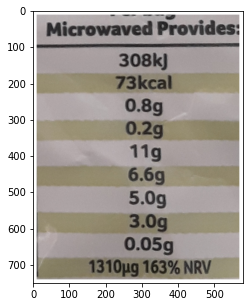

In [20]:
image = cropped_table

feature_extractor = DetrFeatureExtractor()
encoding = feature_extractor(image, return_tensors="pt")
encoding.keys()

model = TableTransformerForObjectDetection.from_pretrained("microsoft/table-transformer-structure-recognition")

with torch.no_grad():
    outputs = model(**encoding)

# colors for visualization
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]
#rows = []
cols = []

def plot_results(pil_img, scores, labels, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    colors = COLORS * 100
    for score, label, (xmin, ymin, xmax, ymax), c  in zip(scores.tolist(), labels.tolist(), boxes.tolist(), colors):
        
        #if (xmax-xmin) > 3*(ymax-ymin):
        if (xmax-xmin) < (ymax-ymin):
            ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, color=c, linewidth=3))
            #cropped_row = pil_img[int(ymin):int(ymax), int(xmin):int(xmax)]
            cropped_col = pil_img[int(ymin):int(ymax), int(xmin):int(xmax)]
            #rows.append(cropped_row)
            
            # adding lines for padding:
            WHITE = [255,255,255]
            cropped_col = cv2.copyMakeBorder(cropped_col,10,10,10,10,cv2.BORDER_CONSTANT,value=WHITE)
            # lines for padding
            
            cols.append(cropped_col)
            
            text = f'{model.config.id2label[label]}: {score:0.2f}'
            ax.text(xmin, ymin, text, fontsize=15, bbox=dict(facecolor='yellow', alpha=0.5))
            plt.figure(figsize=(5,5))
            plt.imshow(cropped_col)
    #plt.axis('off')
    #plt.show()
    
target_sizes = [(image.shape[0],image.shape[1])]
results = feature_extractor.post_process_object_detection(outputs, threshold=0.6, target_sizes=target_sizes)[0]
plot_results(image, results['scores'], results['labels'], results['boxes'])

#model.config.id2label

### Text Extraction ###

[2025/09/09 10:49:14] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='C:\\Users\\SCC/.paddleocr/whl\\cls\\ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='C:\\Users\\SCC/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0

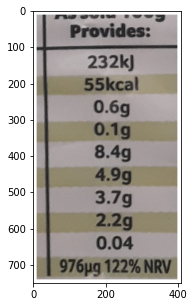

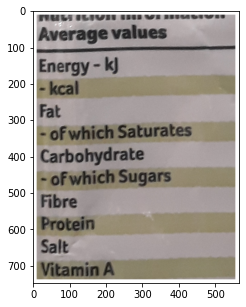

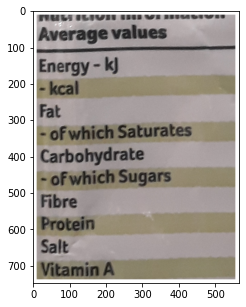

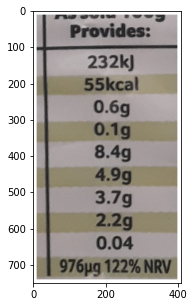

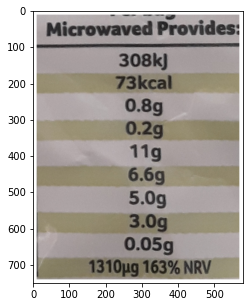

In [21]:
model = PaddleOCR(use_angle_cls=True, lang='en')
cols_copy = cols.copy()
#######################
temp_listt = []
#######################

for item in cols_copy:
    plt.figure(figsize=(5,5))
    plt.imshow(item)
    result = model.ocr(item,cls=True)
    #print('RESULTTTTTTTTTTTT')
    for j in range(len(result[0])):
        #print(result[0][j][-1][0])
        if len(temp_listt)==0:
            if 'Carbo' in result[0][j][-1][0]:
                temp_listt.append(item)
                cols_copy.remove(item)
                
temp_listt.extend(cols_copy)         
print(len(temp_listt))
nutrition_dict = {}

for i in range(len(temp_listt)):
    plt.figure(figsize=(5,5))
    plt.imshow(temp_listt[i])
    result = model.ocr(temp_listt[i],cls=True)
    print('RESULTTTTTTTTTTTT')
    for j in range(len(result[0])):
        print(result[0][j][-1][0])
        if i==0:
            nutrition_dict[result[0][j][-1][0]] = []
        else:
            keys = list(nutrition_dict)
            nutrition_dict[keys[j]].append(str(result[0][j][-1][0]).replace(',','.'))
            
print(nutrition_dict)

### Key-Value pairs formation ###

In [24]:
for i in range(len(result[0])):
    #print(result[0][i][-1][0])

    if i-1>=0 and not any(char.isdigit() for char in result[0][i-1][-1][0]):
        nutrition_dict[result[0][i-1][-1][0]] = []

        if any(char.isdigit() for char in result[0][i][-1][0]):
            nutrition_dict[result[0][i-1][-1][0]].append(str(result[0][i][-1][0]).replace(',','.'))

            if i+1<len(result[0]) and any(char.isdigit() for char in result[0][i+1][-1][0]):
                nutrition_dict[result[0][i-1][-1][0]].append(str(result[0][i+1][-1][0]).replace(',','.'))
                
obj = json.dumps(nutrition_dict, indent=4)
print(obj)
#print(nutrition_dict)

{
    "Average values": [
        "Provides:",
        "Microwaved Provides"
    ],
    "Energy-kJ": [
        "232kJ",
        "308kJ"
    ],
    "-kcal": [
        "55kcal",
        "73kcal"
    ],
    "Fat": [
        "0.6g",
        "0.8g"
    ],
    "-oFwhich Saturates": [
        "0.1g",
        "0.2g"
    ],
    "Carbohydrate": [
        "8.4g",
        "11g"
    ],
    "-oFwhich Sugars": [
        "4.9g",
        "6.6g"
    ],
    "Fibre": [
        "3.7g",
        "5.0g"
    ],
    "Protein": [
        "2.2g",
        "3.0g"
    ],
    "Salt": [
        "0.04",
        "0.05g"
    ],
    "Vitamin A": [
        "976ug 122%NRV",
        "1310g 163%NRV"
    ],
    "Microwaved Provides": [
        "308kJ",
        "73kcal"
    ]
}
